1. Download the two images, [`bird.png`](https://drive.google.com/file/d/17al7QkCrihd1_vYPenS0YmOvKbyS0jB1/view?usp=drive_link) and [`bunny.png`](https://drive.google.com/file/d/1t7WnYrrwnUxbMZ38Cv6Gv41n-tVKjyHF/view?usp=drive_link). Place the two images in the
`files` folder. Use the `process_image()` function to process the
two images, and name the processed images `image3` and `image4`, respectively. Feed
the two processed images to the pretrained VQGAN to obtain two reconstructed
images, `reconstruct3` and `reconstruct4`.

In [ ]:
!pip install omegaconf pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.7 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/markhliu/taming-transformers

Cloning into 'taming-transformers'...
remote: Enumerating objects: 1236, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 1236 (delta 1), reused 1 (delta 1), pack-reused 1230 (from 2)
Receiving objects: 100% (1236/1236), 148.34 MiB | 26.36 MiB/s, done.
Resolving deltas: 100% (257/257), done.


In [ ]:
import sys
sys.path.append("./taming-transformers")

In [ ]:
import requests, os

url1=('https://heibox.uni-heidelberg.de/f/'
      '140747ba53464f49b476/?dl=1')
url2=('https://heibox.uni-heidelberg.de/f/'
      '6ecf2af6c658432c8298/?dl=1')

file1="files/vqgan_imagenet_f16_1024.ckpt"
file2="files/vqgan_imagenet_f16_1024.yaml"    #Defines URLs and filenames for the model weights and configuration

# Create the 'files' directory if it doesn't exist
os.makedirs(os.path.dirname(file1), exist_ok=True)

if not os.path.exists(file1):
    fb=requests.get(url1)
    with open(file1,"wb") as f:
        f.write(fb.content)    #If the weights file is missing, download it from the specified URL.

if not os.path.exists(file2):
    fb=requests.get(url2)
    with open(file2,"wb") as f:
        f.write(fb.content)    #If the configuration file is missing, download it from the specified URL.

In [ ]:
import torch
torch.set_grad_enabled(False)    #Disables gradient computation to speed up inference

device = "cuda:0" if torch.cuda.is_available() else "cpu"

from omegaconf import OmegaConf
from taming.models.vqgan import VQModel

def load_model():
    config = OmegaConf.load(file2)    #Loads model configuration
    model = VQModel(**config.model.params).to(device)    #Imports the VQGAN model from the GitHub repository
    sd = torch.load(file1)["state_dict"]
    missing, unexpected = model.load_state_dict(sd,
                            strict=False)    #Loads pretrained weights to the VQGAN model
    return model

In [ ]:
import PIL
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def process_image(file_name):    #Defines a process_image() function to center crop images and resize them
    size=384
    img=PIL.Image.open(file_name)
    s = min(img.size)
    r = size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [size])
    return torch.unsqueeze(T.ToTensor()(img), 0)*2-1

def image_to_sequence(model,image):
    z=model.encoder(image.to(device))
    z=model.quant_conv(z)
    z_q, _ , indices= model.quantize(z)
    int_sequence = indices[2]
    return int_sequence

def sequence_to_image(model,sequence):
    z_q2 = model.quantize.embedding(sequence)
    z_q2 = z_q2.permute(1,0).view((1,256,24,24))
    z_post2 = model.post_quant_conv(z_q2)
    z_recon2 = model.decoder(z_post2)
    return z_recon2

In [ ]:
import matplotlib.pyplot as plt

image3 = process_image("files/bird.png")
image4 = process_image("files/bunny.png")

print(f"image3: {image3.shape}")
print(f"image4: {image4.shape}")

model = load_model()

reconstruct3, _ = model(image3.to(device))
reconstruct4, _ = model(image4.to(device))

print(f"reconstruct3: {reconstruct3.shape}")
print(f"reconstruct4: {reconstruct4.shape}")

image3: torch.Size([1, 3, 384, 384])
image4: torch.Size([1, 3, 384, 384])
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
reconstruct3: torch.Size([1, 3, 384, 384])
reconstruct4: torch.Size([1, 3, 384, 384])


2. Place the two original images, image3 and image4, and the two reconstructed ones, reconstruct3 and reconstruct4, in a list imgs. Plot the four images in a  1×4  grid, and add a caption of either original or reconstructed above each image.

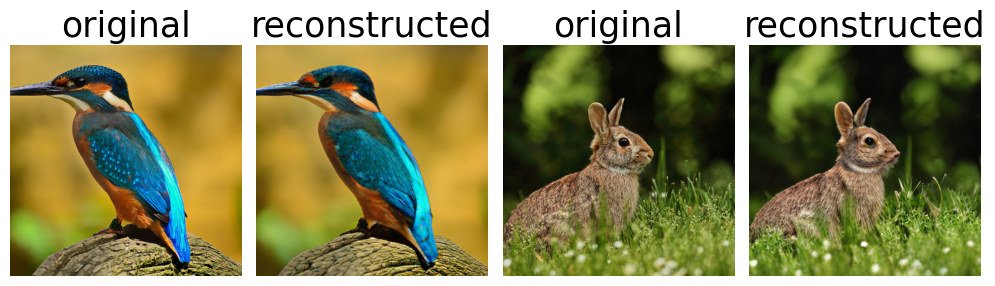

In [ ]:
imgs=[image3[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct3[0].cpu().permute(1,2,0)*0.5+0.5,
      image4[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct4[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["original","reconstructed"] * 2#atentie ai 4 imaginii in total!!!!!!!!!!!
plt.figure(figsize=(10,5),dpi=100)
for i in range(4):    #Displays the original and reconstructed images
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=25)
    plt.axis('off')
plt.tight_layout()
plt.show()

3. Find out the quantized latent representation for the fish image, and name it z2_q. Find out the sequence of integers that represent the fish image, and call it int_sequence2. Print out the  576  values in int_sequence2.

In [ ]:
import requests, os

url1=('https://heibox.uni-heidelberg.de/f/'
      '140747ba53464f49b476/?dl=1')
url2=('https://heibox.uni-heidelberg.de/f/'
      '6ecf2af6c658432c8298/?dl=1')

file1="files/vqgan_imagenet_f16_1024.ckpt"
file2="files/vqgan_imagenet_f16_1024.yaml"    #Defines URLs and filenames for the model weights and configuration

if not os.path.exists(file1):
    fb=requests.get(url1)
    with open(file1,"wb") as f:
        f.write(fb.content)    #If the weights file is missing, download it from the specified URL.

if not os.path.exists(file2):
    fb=requests.get(url2)
    with open(file2,"wb") as f:
        f.write(fb.content)    #If the configuration file is missing, download it from the specified URL.

In [ ]:
import torch
torch.set_grad_enabled(False)    #Disables gradient computation to speed up inference

device = "cuda:0" if torch.cuda.is_available() else "cpu"

from omegaconf import OmegaConf
from taming.models.vqgan import VQModel

config = OmegaConf.load(file2)    #Loads model configuration
model = VQModel(**config.model.params).to(device)    #Imports the VQGAN model from the GitHub repository
sd = torch.load(file1)["state_dict"]
missing, unexpected = model.load_state_dict(sd,
                        strict=False)    #Loads pretrained weights to the VQGAN model

Working with z of shape (1, 256, 16, 16) = 65536 dimensions.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.


In [ ]:
import PIL
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def process_image(file_name):    #Defines a process_image() function to center crop images and resize them
    size=384
    img=PIL.Image.open(file_name)
    s = min(img.size)
    r = size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [size])
    return torch.unsqueeze(T.ToTensor()(img), 0)*2-1

image1=process_image("files/bird.png")
image2=process_image("files/bunny.png")    #Applies the process_image() function on the cat and fish images
print(f"the shape of the original image is {image1.shape}")
reconstruct1=model((image1).to(device))[0]
reconstruct2=model((image2).to(device))[0]    #Reconstructs the cat and fish images using the pretrained VQGAN
print(f"reconstructed image's shape is {reconstruct2.shape}")

the shape of the original image is torch.Size([1, 3, 384, 384])
reconstructed image's shape is torch.Size([1, 3, 384, 384])


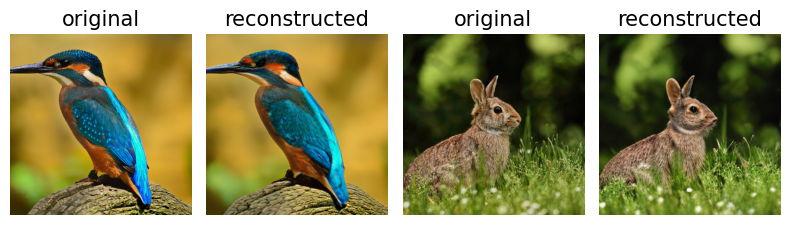

In [ ]:
import matplotlib.pyplot as plt

imgs=[image1[0].cpu().permute(1,2,0)*0.5+0.5,    #Places the two originals and the two reconstructed images in a list
      reconstruct1[0].cpu().permute(1,2,0)*0.5+0.5,
      image2[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct2[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["original","reconstructed"]*2    #Prepares four captions

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=15)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
z2=model.encoder(image1.to(device))
z2=model.quant_conv(z2)
print(f"the shape of the latent representation is {z2.shape}")

z2_q, _ , indices= model.quantize(z2)    #Quantizes the latent vectors by replacing each one with its nearest neighbor in the codebook
int_sequence2 = indices[2]    #Extracts the sequence of integers (indices of the selected codebook vectors)
#print(int_sequence)

print(f"z2_q: {z2_q.shape}")
print(f"int_sequence2: {int_sequence2.shape}")
print(f"int_sequence2: {int_sequence2}")

the shape of the latent representation is torch.Size([1, 256, 24, 24])
z2_q: torch.Size([1, 256, 24, 24])
int_sequence2: torch.Size([576])
int_sequence2: tensor([  66,  553,  695,  828,  600,  316,  416,  436,  416,  808,   80,   80,
         695,  675,  695,  328,  287,    4,  323,  551,  339,  551,  325,  316,
         553,  808,   80,  550,   37,  514,  171,  633,  607,  550,  416,  308,
         577,  577,  828,  435,  577,   37,   72,  638,   37,  638,   37,  147,
         941,  537,  537,  416,  808,   61,  928,  761,    6,  774,  255,  119,
         416,  308,  678,  961,  316,  695,  258,  245,   72,   72,  751,  553,
         537,  464,  517,   31,  710,  845,  508,  626,  870,  261,  714,  701,
          12,  416,  117,  808,  316,  316,  143,  220,   47,  313,  316,  316,
         254,  444,  444,  438,  966,  572,  576,  731,  376,  961,  681,  312,
         402,  695,  316,  436,  695,  751,  551,  313,  660,    4,  908,  994,
         797,   82,  731,  887,  545,    0,  7

4. Map each integer in int_sequence2 to its corresponding feature vector in the codebook to assemble a complete quantized latent representation z2_q2. Pass z2_q2 through the VQGAN decoder to reconstruct the fish image, and name the reconstructed image z2_recon2.

In [ ]:
z_q2 = model.quantize.embedding(int_sequence2)
z_q2 = z_q2.permute(1,0).view(z2_q.shape)    #Builds a quantized latent representation, z_q2, based on the sequence of integers
z_post2 = model.post_quant_conv(z_q2)
z_recon2 = model.decoder(z_post2)    #Converts the latent representation into an image using the VQGAN decoder

In [ ]:
print(f"z2_recon2 shape: {z_recon2.shape}")

z2_recon2 shape: torch.Size([1, 3, 384, 384])


5. First, reconstruct the fish image based on the quantized latent representation first generated, z2_q, in Exercise 3, and name the reconstructed fish image z2_recon. Plot z2_recon and z2_recon2 side by side in a 1×2 grid to compare them.

In [ ]:
import PIL
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def process_image(file_name):    #Defines a process_image() function to center crop images and resize them
    size=384
    img=PIL.Image.open(file_name)
    s = min(img.size)
    r = size / s
    s = (round(r * img.size[1]), round(r * img.size[0]))
    img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    img = TF.center_crop(img, output_size=2 * [size])
    return torch.unsqueeze(T.ToTensor()(img), 0)*2-1

image1=process_image("files/fish.png")
image2=process_image("files/bunny.png")    #Applies the process_image() function on the cat and fish images
print(f"the shape of the original image is {image1.shape}")
reconstruct1=model((image1).to(device))[0]
reconstruct2=model((image2).to(device))[0]    #Reconstructs the cat and fish images using the pretrained VQGAN
print(f"reconstructed image's shape is {reconstruct2.shape}")

the shape of the original image is torch.Size([1, 3, 384, 384])
reconstructed image's shape is torch.Size([1, 3, 384, 384])


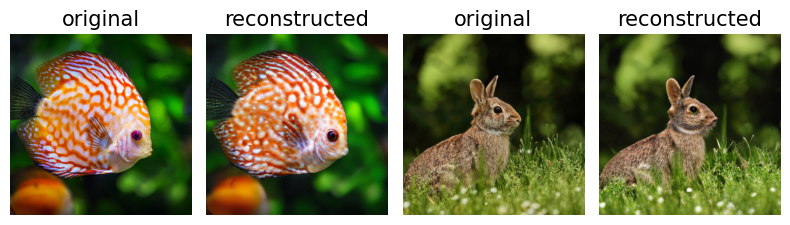

In [ ]:
import matplotlib.pyplot as plt

imgs=[image1[0].cpu().permute(1,2,0)*0.5+0.5,    #Places the two originals and the two reconstructed images in a list
      reconstruct1[0].cpu().permute(1,2,0)*0.5+0.5,
      image2[0].cpu().permute(1,2,0)*0.5+0.5,
      reconstruct2[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["original","reconstructed"]*2    #Prepares four captions

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=15)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
z2=model.encoder(image1.to(device))
z2=model.quant_conv(z2)
print(f"the shape of the latent representation is {z2.shape}")

z2_q, _ , indices= model.quantize(z2)    #Quantizes the latent vectors by replacing each one with its nearest neighbor in the codebook
int_sequence2 = indices[2]

the shape of the latent representation is torch.Size([1, 256, 24, 24])


In [ ]:
z_q2 = model.quantize.embedding(int_sequence2)
z_q2 = z_q2.permute(1,0).view(z2_q.shape)    #Builds a quantized latent representation, z_q2, based on the sequence of integers
z_post2 = model.post_quant_conv(z_q2)
z_recon2 = model.decoder(z_post2)

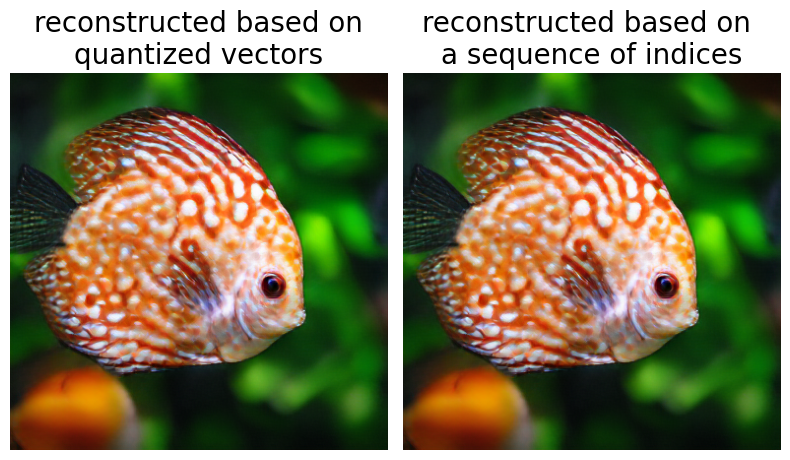

In [ ]:
z2_post = model.post_quant_conv(z2_q)
z2_recon = model.decoder(z2_post)    #Reconstructs the cat image using the quantized latent representation, z_q

imgs=[z2_recon[0].cpu().permute(1,2,0)*0.5+0.5,
      z_recon2[0].cpu().permute(1,2,0)*0.5+0.5]

captions=["reconstructed based on\nquantized vectors",
          "reconstructed based on \na sequence of indices"]

plt.figure(figsize=(8,5),dpi=100)
for i in range(2):    #Compares the reconstructed image based on z_q to the image based on the sequence of indices
    plt.subplot(1,2,i+1)
    plt.imshow(imgs[i].clamp(0,1))
    plt.title(captions[i],fontsize=20)
    plt.axis('off')
plt.tight_layout()
plt.show()